In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("/backup/Intern/combine_skindiseaseclassifier_devraj")
SPLIT_DIR = PROJECT_ROOT / "data" / "splits"
REPORT_DIR = PROJECT_ROOT / "reports" / "dataset_balance"
MD_DIR = PROJECT_ROOT / "markdown_reports"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MD_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

In [2]:
rows = []

for split in ["train", "val", "test"]:
    split_path = SPLIT_DIR / split

    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        count = sum(
            1 for p in class_dir.rglob("*")
            if p.is_file() or p.is_symlink()
        )

        rows.append({
            "split": split,
            "class_name": class_dir.name,
            "image_count": count
        })

df = pd.DataFrame(rows)
df

,split,class_name,image_count
0,train,acne_vulgaris,1727
1,train,atopic_dermatitis,1376
2,train,basal_cell_carcinoma,4247
3,train,contact_dermatitis,1062
4,train,drug_eruptions,1115
5,train,folliculitis,825
6,train,fungal_nail_infections,844
7,train,lupus_related_skin_lesions,900
8,train,melanoma,6367
9,train,plaque_psoriasis,2342


In [3]:
pivot = df.pivot(index="class_name", columns="split", values="image_count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)
pivot = pivot.sort_values("total", ascending=False)

pivot

split,test,train,val,total
class_name,,,,
melanoma,1364,6367,1364,9095
basal_cell_carcinoma,910,4247,910,6067
plaque_psoriasis,502,2342,502,3346
acne_vulgaris,370,1727,370,2467
warts,300,1404,300,2004
atopic_dermatitis,294,1376,295,1965
tinea_corporis,289,1353,290,1932
vitiligo,251,1175,251,1677
drug_eruptions,238,1115,239,1592


In [4]:
csv_path = REPORT_DIR / "class_counts.csv"
pivot.to_csv(csv_path)

csv_path

PosixPath('/backup/Intern/combine_skindiseaseclassifier_devraj/reports/dataset_balance/class_counts.csv')

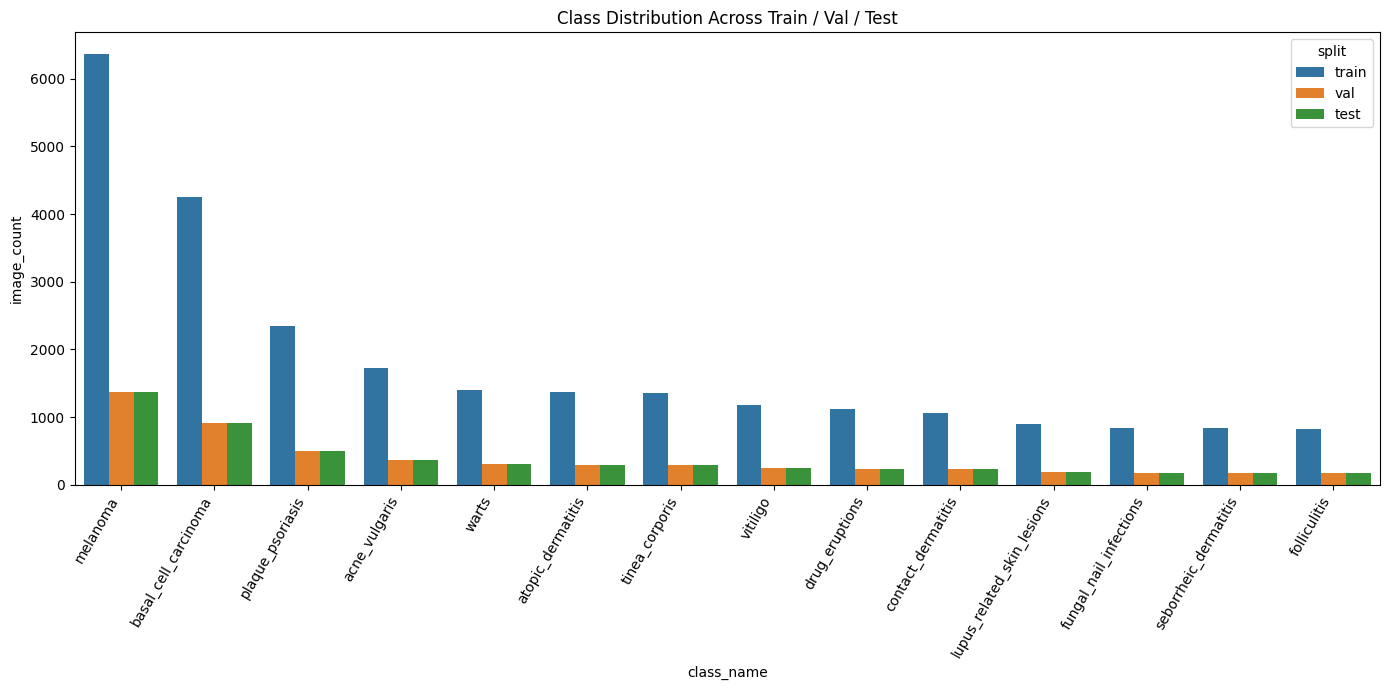

PosixPath('/backup/Intern/combine_skindiseaseclassifier_devraj/reports/dataset_balance/class_distribution.png')

In [5]:
plot_df = pivot.reset_index().melt(
    id_vars="class_name",
    value_vars=["train", "val", "test"],
    var_name="split",
    value_name="image_count"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x="class_name", y="image_count", hue="split")
plt.xticks(rotation=60, ha="right")
plt.title("Class Distribution Across Train / Val / Test")
plt.tight_layout()

plot_path = REPORT_DIR / "class_distribution.png"
plt.savefig(plot_path, dpi=200)
plt.show()

plot_path

In [6]:
train_counts = pivot["train"]
largest_class = train_counts.max()
smallest_class = train_counts.min()
imbalance_ratio = largest_class / smallest_class

largest_class_name = train_counts.idxmax()
smallest_class_name = train_counts.idxmin()

largest_class_name, largest_class, smallest_class_name, smallest_class, imbalance_ratio

('melanoma',
 np.int64(6367),
 'folliculitis',
 np.int64(825),
 np.float64(7.717575757575758))

In [7]:
md_path = MD_DIR / "dataset_balance_summary.md"

with md_path.open("w", encoding="utf-8") as f:
    f.write("# Dataset Balance Summary\n\n")
    f.write(f"Dataset split folder: `{SPLIT_DIR}`\n\n")

    f.write("## Total Images Per Split\n\n")
    split_totals = df.groupby("split")["image_count"].sum()
    f.write("| Split | Images |\n")
    f.write("|---|---:|\n")
    for split, count in split_totals.items():
        f.write(f"| {split} | {count:,} |\n")

    f.write("\n## Class Counts\n\n")
    f.write("| Class | Train | Val | Test | Total |\n")
    f.write("|---|---:|---:|---:|---:|\n")

    for class_name, row in pivot.iterrows():
        f.write(
            f"| {class_name} | {row['train']:,} | {row['val']:,} | "
            f"{row['test']:,} | {row['total']:,} |\n"
        )

    f.write("\n## Train Imbalance\n\n")
    f.write(f"Largest train class: `{largest_class_name}` with **{largest_class:,}** images.\n\n")
    f.write(f"Smallest train class: `{smallest_class_name}` with **{smallest_class:,}** images.\n\n")
    f.write(f"Train imbalance ratio: **{imbalance_ratio:.2f}:1**.\n\n")

    f.write("## Interpretation\n\n")
    f.write(
        "The dataset is imbalanced, so PyTorch models should use "
        "`WeightedRandomSampler` during training only. Validation and test sets "
        "should remain unchanged to keep evaluation honest.\n"
    )

md_path

PosixPath('/backup/Intern/combine_skindiseaseclassifier_devraj/markdown_reports/dataset_balance_summary.md')

In [8]:
import subprocess

subprocess.run(
    ["python3", str(PROJECT_ROOT / "scripts" / "update_project_structure.py")],
    cwd=PROJECT_ROOT,
    check=True
)

Updated: /backup/Intern/combine_skindiseaseclassifier_devraj/PROJECT_STRUCTURE.txt


CompletedProcess(args=['python3', '/backup/Intern/combine_skindiseaseclassifier_devraj/scripts/update_project_structure.py'], returncode=0)